In [1]:
import os
import numpy as np
import tensorflow as tf
from sklearn.model_selection import StratifiedKFold
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, CSVLogger, EarlyStopping
from tensorflow.keras.regularizers import l2
from tensorflow.keras import layers, models, Input
from tqdm import tqdm
import gc 
import sys
import nibabel as nib

2026-01-12 14:19:23.367257: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-01-12 14:19:24.105432: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-01-12 14:19:24.308199: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-01-12 14:19:25.808483: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
%load_ext autoreload
%autoreload 2

# Pega o diretório atual e sobe um nível ('..')
project_root = os.path.abspath('..')

# Adiciona este diretório ao sys.path se ele ainda não estiver lá
if project_root not in sys.path:
    sys.path.append(project_root)

# --- Seus imports originais ---
import utils.processamento_dados as proc_dados
import utils.metricas_e_visualizacao as met_vil

In [3]:
# Configuração de GPU
from tensorflow.keras import mixed_precision
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("GPU habilitada com sucesso!")
    except RuntimeError as e:
        print(e)

mixed_precision.set_global_policy("mixed_float16")
tf.get_logger().setLevel('ERROR')

GPU habilitada com sucesso!


I0000 00:00:1768238449.091140   11485 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:21:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1768238449.093278   11485 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:21:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1768238449.093327   11485 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:21:00.0/numa_node
Your kernel may have been built without NUMA support.


In [4]:
# # ==========================================
# # 1. DEFINIÇÃO DO MODELO
# # ==========================================
# def create_model_3d(input_shape, n_classes):
#     inputs = Input(shape=input_shape)

#     # Camada 1
#     x = layers.Conv3D(4, (3, 3, 3), padding='same', kernel_regularizer=l2(0.01))(inputs)
#     x = layers.BatchNormalization()(x)
#     x = layers.LeakyReLU(negative_slope=0.3)(x)
#     x = layers.AveragePooling3D(pool_size=(3, 3, 3), padding='same')(x)
#     x = layers.Dropout(0.3)(x)

#     # Camada 2
#     x = layers.Conv3D(8, (3, 3, 3), padding='same', kernel_regularizer=l2(0.01))(x)
#     x = layers.BatchNormalization()(x)
#     x = layers.LeakyReLU(negative_slope=0.3)(x)
#     x = layers.AveragePooling3D(pool_size=(3, 3, 3), padding='same')(x)
#     x = layers.Dropout(0.3)(x)

#     # Camada 3
#     x = layers.Conv3D(16, (3, 3, 3), padding='same', kernel_regularizer=l2(0.01))(x)
#     x = layers.BatchNormalization()(x)
#     x = layers.LeakyReLU(negative_slope=0.3)(x)
#     x = layers.AveragePooling3D(pool_size=(3, 3, 3), padding='same')(x)
#     x = layers.Dropout(0.3)(x)

#     # Classificador
#     x = layers.Flatten()(x)
#     x = layers.Dense(16, kernel_regularizer=l2(0.01))(x)
#     x = layers.BatchNormalization()(x)
#     x = layers.Dropout(0.3)(x)
#     x = layers.LeakyReLU(negative_slope=0.3)(x)

#     if n_classes == 2:
#         outputs = layers.Dense(1, activation='sigmoid')(x)
#     else:
#         outputs = layers.Dense(n_classes, activation='softmax')(x)

#     model = models.Model(inputs=inputs, outputs=outputs, name="Small_Leaky_3D_Model")
#     return model


In [5]:
def create_model_3d(input_shape, n_classes):
    # Entrada
    inputs = Input(shape=input_shape)  # (D, H, W, C)

    # === Camada 1 ===
    x = layers.Conv3D(4, (3, 3, 3), padding='same', kernel_regularizer=l2(0.01))(inputs)
    x = layers.Conv3D(4, (3, 3, 3), padding='same', kernel_regularizer=l2(0.01))(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(negative_slope=0.3)(x)
    x = layers.AveragePooling3D(pool_size=(4, 4, 4), padding='same')(x)
    x = layers.Dropout(0.3)(x)

    # === Camada 2 ===
    x = layers.Conv3D(8, (3, 3, 3), padding='same', kernel_regularizer=l2(0.01))(x)
    x = layers.Conv3D(8, (3, 3, 3), padding='same', kernel_regularizer=l2(0.01))(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(negative_slope=0.3)(x)
    x = layers.AveragePooling3D(pool_size=(3, 3, 3), padding='same')(x)
    x = layers.Dropout(0.3)(x)

    # === Camada 3 ===
    x = layers.Conv3D(16, (3, 3, 3), padding='same', kernel_regularizer=l2(0.01))(x)
    x = layers.Conv3D(16, (3, 3, 3), padding='same', kernel_regularizer=l2(0.01))(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(negative_slope=0.3)(x)
    x = layers.AveragePooling3D(pool_size=(3, 3, 3), padding='same')(x)
    x = layers.Dropout(0.3)(x)

    # === Classificador ===
    x = layers.Flatten()(x)

    x = layers.Dense(16, kernel_regularizer=l2(0.01))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.LeakyReLU(negative_slope=0.3)(x)

    # === Adaptação da Saída ===
    if n_classes == 2:
        # Binário: 1 neurônio com Sigmoid (para funcionar com binary_crossentropy)
        outputs = layers.Dense(1, activation='sigmoid')(x)
    else:
        # Multiclasse: N neurônios com Softmax
        outputs = layers.Dense(n_classes, activation='softmax')(x)

    model = models.Model(inputs=inputs, outputs=outputs, name="Small_Leaky_3D_Model")
    
    return model

In [6]:
# CONFIGURAÇÕES E CAMINHOS
dir_base = "/mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/ADNI"
data_3t_dir = f"{dir_base}/ADNI_3_4_NORMALIZED"

# Pasta de resultados K-FOLD
results_dir_base = f'{dir_base}/results_only_3t_kfold'
os.makedirs(results_dir_base, exist_ok=True)

n = len(os.listdir(results_dir_base))
folder_name = f"kfold_experiment_{n+1}"
results_dir = os.path.join(results_dir_base, folder_name)
os.makedirs(results_dir, exist_ok=True)
print(f"Resultados serão salvos em: {results_dir}")

adni_class_names = ['cn', 'ad']

Resultados serão salvos em: /mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/ADNI/results_only_3t_kfold/kfold_experiment_8


In [7]:
# --- 1. CONFIGURAÇÃO DE CAMINHOS ---
dir_train = os.path.join(data_3t_dir, "train")
dir_val = os.path.join(data_3t_dir, "validation")
dir_test = os.path.join(data_3t_dir, "test")

# Mapeamento de classes 
class_map = {
    "cn": 0,  # Controle Normal
    "ad": 1  # Alzheimer
}

print("=== ETAPA 1: INDEXANDO ARQUIVOS (SALVANDO CAMINHOS) ===")

all_file_paths = []
all_labels = []

# Função para varrer pastas recursivamente
def indexar_arquivos(diretorio_base):
    caminhos = []
    labels = []
    
    # Walk percorre todas as subpastas
    for root, dirs, files in os.walk(diretorio_base):
        for file in files:
            if file.endswith(".nii") or file.endswith(".nii.gz"):
                full_path = os.path.join(root, file)
                
                # Tenta descobrir o label pelo nome da pasta pai
                folder_name = os.path.basename(root)
                
                # Verifica se a pasta corresponde a uma classe conhecida
                label = None
                for key, val in class_map.items():
                    if key in folder_name: # Ex: se "CN" está em "train/CN"
                        label = val
                        break
                
                if label is not None:
                    caminhos.append(full_path)
                    labels.append(label)
                else:
                    pass
                    
    return caminhos, labels

# Coleta os caminhos
paths_train, y_train_list = indexar_arquivos(dir_train)
paths_val, y_val_list = indexar_arquivos(dir_val)
paths_test, y_test_list = indexar_arquivos(dir_test)

# Junta tudo em uma lista única (pra fazer os folds)
final_paths = paths_train + paths_val + paths_test
final_labels = y_train_list + y_val_list + y_test_list

total_files = len(final_paths)
print(f"Indexação concluída.")
print(f"Total de arquivos encontrados: {total_files}")

if total_files == 0:
    print("Erro: Nenhum arquivo encontrado. Verifique os caminhos e o 'class_map'.")
    sys.exit(1)

print("\n=== ETAPA 2: PREPARANDO MEMÓRIA ===")

# Descobre o shape carregando apenas o primeiro arquivo
try:
    print("Lendo primeiro arquivo para pegar dimensões...")
    img_obj = nib.load(final_paths[0])
    img_data = img_obj.get_fdata()
    sample_shape = img_data.shape
    
    print(f"Dimensões detectadas: {sample_shape}")
    print(f"Tipo de dado original: {img_data.dtype}")
    
except Exception as e:
    print(f"Erro ao ler arquivo de amostra: {e}")
    sys.exit(1)

# Aloca o Array Gigante
try:
    X_all = np.zeros((total_files, *sample_shape), dtype=np.float32)
    y_all = np.array(final_labels, dtype=np.int16)
    
    gb_use = X_all.nbytes / (1024**3)
    print(f"Memória alocada: {gb_use:.2f} GB")
    
except MemoryError:
    print("ERRO FATAL: Falta RAM para criar X_all.")
    sys.exit(1)


print("\n=== ETAPA 3: CARREGANDO DADOS (LOOP FINAL) ===")

# Loop pelos caminhos para carregar os dados
for i, file_path in enumerate(final_paths):
    try:
        # Carrega NIfTI
        img = nib.load(file_path)
        data = img.get_fdata()
        data = data.astype(np.float32)
        
        # Insere no array
        X_all[i] = data
        
        # Log de progresso a cada 100 imagens
        if i % 100 == 0:
            print(f"  > Processado {i}/{total_files}...")
            
    except Exception as e:
        print(f"Erro ao ler arquivo {file_path}: {e}")
        # Opcional: zerar essa posição ou tratar depois

print("\n=== FINALIZADO ===")
print(f"Shape final X_all: {X_all.shape}")
print(f"Shape final y_all: {y_all.shape}")

# Limpeza final
del final_paths, final_labels
gc.collect()

=== ETAPA 1: INDEXANDO ARQUIVOS (SALVANDO CAMINHOS) ===
Indexação concluída.
Total de arquivos encontrados: 1003

=== ETAPA 2: PREPARANDO MEMÓRIA ===
Lendo primeiro arquivo para pegar dimensões...
Dimensões detectadas: (156, 195, 160)
Tipo de dado original: float64
Memória alocada: 18.19 GB

=== ETAPA 3: CARREGANDO DADOS (LOOP FINAL) ===
  > Processado 0/1003...
  > Processado 100/1003...
  > Processado 200/1003...
  > Processado 300/1003...
  > Processado 400/1003...
  > Processado 500/1003...
  > Processado 600/1003...
  > Processado 700/1003...
  > Processado 800/1003...
  > Processado 900/1003...
  > Processado 1000/1003...

=== FINALIZADO ===
Shape final X_all: (1003, 156, 195, 160)
Shape final y_all: (1003,)


171

In [8]:
# CONFIGURAÇÕES GERAIS
K_FOLDS = 5
BATCH_SIZE = 8      
LEARNING_RATE = 0.001
EPOCHS = 50

# Listas globais para resultados
fold_accuracies = []
fold_aucs = []
aggregated_true_labels = []
aggregated_pred_labels = []

# FUNÇÕES AUXILIARES (Balanceamento e Generators)
def augment_and_balance_in_ram(X_full, y_full, indices):
    # 1. Pega labels deste fold para contagem
    y_subset = y_full[indices]
    
    # 2. Identifica classe minoritária
    counts = np.bincount(y_subset)
    minority_class = np.argmin(counts)
    majority_class = np.argmax(counts)
    n_minority = counts[minority_class]
    n_majority = counts[majority_class]
    
    print(f"  Balanceamento: Majoritária ({majority_class}): {n_majority} | Minoritária ({minority_class}): {n_minority}")
    
    # 3. Calcula tamanho final (Majoritária + 4x Minoritária)
    # Ajuste o multiplicador se necessário
    total_final = n_majority + (n_minority * 4)
    
    input_shape = X_full[0].shape
    # Adiciona canal extra se não existir (D, H, W, 1)
    final_shape = (total_final, *input_shape, 1)
    
    print(f"Alocando memória para {total_final} amostras...")
    
    # 4. Alocação
    try:
        X_aug = np.empty(final_shape, dtype=np.float16) 
        y_aug = np.empty((total_final,), dtype=np.int16)
    except MemoryError:
        print("ERRO FATAL: Memória RAM insuficiente para Augmentation.")
        raise
        
    # 5. Preenchimento e Augmentation
    cursor = 0
    total_indices = len(indices)
    
    for idx, i in enumerate(indices):
        orig = X_full[i].astype(np.float32) 
        lbl = y_full[i].astype(np.int16)
        
        # Garante dimensão do canal
        if len(orig.shape) == 3:
            orig_expanded = np.expand_dims(orig, axis=-1)
        else:
            orig_expanded = orig

        if lbl == majority_class:
            X_aug[cursor] = orig_expanded.astype(np.float16)
            y_aug[cursor] = lbl
            cursor += 1
        else:
            # Estratégia para Classe Minoritária: Original + 3 Variações
            # 1. Original
            X_aug[cursor] = orig_expanded
            y_aug[cursor] = lbl
            cursor += 1
            
            # 2. Zoom
            zoom_img = proc_dados.augment_zoom(orig)
            zoom_img = zoom_img.astype(np.float16)
            X_aug[cursor] = np.expand_dims(zoom_img, axis=-1)
            y_aug[cursor] = lbl
            cursor += 1
            
            # 3. Shift
            shift_img = proc_dados.augment_shift(orig)
            shift_img = shift_img.astype(np.float16)
            X_aug[cursor] = np.expand_dims(shift_img, axis=-1)
            y_aug[cursor] = lbl
            cursor += 1
            
            # 4. Rotation
            rot_img = proc_dados.augment_rotation(orig)
            rot_img = rot_img.astype(np.float16)
            X_aug[cursor] = np.expand_dims(rot_img, axis=-1)
            y_aug[cursor] = lbl
            cursor += 1
            
        if idx % 100 == 0:
            print(f"Processando: {idx}/{total_indices}...", end='\r')
            
    print(f"\n Dados Augmentados na RAM! Shape: {X_aug.shape}")
    
    # 6. Embaralhar os dados gerados
    shuf_idxs = np.arange(total_final)
    np.random.shuffle(shuf_idxs)
    
    return X_aug[shuf_idxs], y_aug[shuf_idxs]

def numpy_generator(x_data, y_data):
    """Generator simples que lê do array NumPy e entrega pro TensorFlow"""
    for i in range(len(x_data)):
        yield x_data[i], y_data[i]


INICIANDO FOLD 1/5 (FINE-TUNING)
Gerando Augmentation e Balanceamento na RAM...
  Balanceamento: Majoritária (0): 700 | Minoritária (1): 102
Alocando memória para 1108 amostras...
Processando: 800/802...
 Dados Augmentados na RAM! Shape: (1108, 156, 195, 160, 1)
Configurando tf.data Generators...


I0000 00:00:1768238713.272099   11485 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:21:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1768238713.272177   11485 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:21:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1768238713.272203   11485 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:21:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1768238713.555376   11485 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:21:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1768238713.555595   11485 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:21:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-01-12

Iniciando treinamento...
Epoch 1/50


I0000 00:00:1768238718.414503   13012 service.cc:146] XLA service 0x7f3458018370 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1768238718.414552   13012 service.cc:154]   StreamExecutor device (0): NVIDIA GeForce RTX 3060, Compute Capability 8.6
2026-01-12 14:25:18.662695: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-01-12 14:25:19.182022: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 8907
2026-01-12 14:25:24.245112: E external/local_xla/xla/service/slow_operation_alarm.cc:65] Trying algorithm eng10{k2=3,k13=0,k14=2,k18=0,k23=0} for conv (f16[8,4,156,195,160]{4,3,2,1,0}, u8[0]{0}) custom-call(f16[8,1,156,195,160]{4,3,2,1,0}, f16[4,1,3,3,3]{4,3,2,1,0}, f16[4]{0}), window={size=3x3x3 pad=1_1x1_1x1_1}, dim_labels=bf012_oi012->bf012, custom_call_target="__cudnn$convBiasActivationForwa

    138/Unknown 57s 100ms/step - accuracy: 0.6643 - auc: 0.7330 - loss: 1.3934

...

2026-01-12 14:30:33.723170: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
	 [[IteratorGetNext/_2]]
2026-01-12 14:30:33.723251: I tensorflow/core/framework/local_rendezvous.cc:423] Local rendezvous recv item cancelled. Key hash: 10679036752214322336
2026-01-12 14:30:33.723304: I tensorflow/core/framework/local_rendezvous.cc:423] Local rendezvous recv item cancelled. Key hash: 6934646235427923232


139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 0.8340 - auc: 0.8911 - loss: 0.5090

2026-01-12 14:30:47.994241: I tensorflow/core/framework/local_rendezvous.cc:423] Local rendezvous recv item cancelled. Key hash: 6934646235427923232


139/139 ━━━━━━━━━━━━━━━━━━━━ 15s 110ms/step - accuracy: 0.8357 - auc: 0.8936 - loss: 0.5065 - val_accuracy: 0.1294 - val_auc: 0.6627 - val_loss: 1.7270 - learning_rate: 5.0000e-04


2026-01-12 14:30:49.105807: I tensorflow/core/framework/local_rendezvous.cc:423] Local rendezvous recv item cancelled. Key hash: 10679036752214322336
2026-01-12 14:30:49.105891: I tensorflow/core/framework/local_rendezvous.cc:423] Local rendezvous recv item cancelled. Key hash: 6934646235427923232


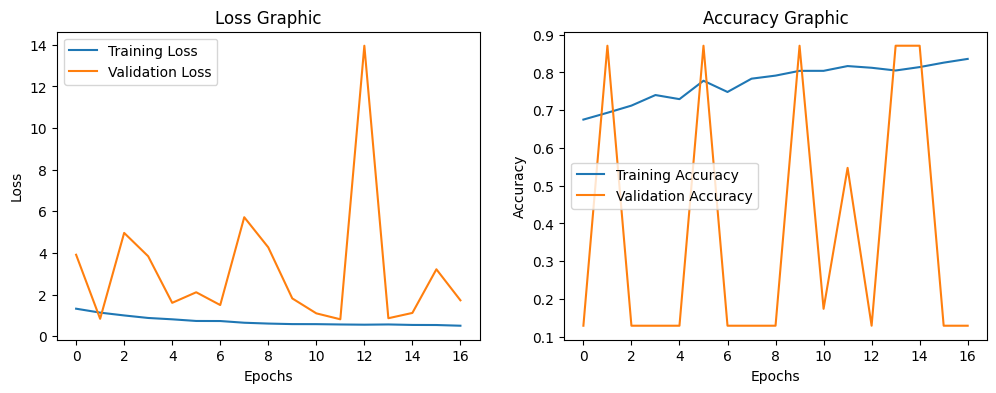

Carregando melhor modelo do fold...


2026-01-12 14:30:56.210264: I tensorflow/core/framework/local_rendezvous.cc:423] Local rendezvous recv item cancelled. Key hash: 10679036752214322336
2026-01-12 14:30:56.210339: I tensorflow/core/framework/local_rendezvous.cc:423] Local rendezvous recv item cancelled. Key hash: 6934646235427923232


  Resultado Fold 1: Acc=0.8706, AUC=0.7349


/mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/Alzheimer-CNN-Detection/3dalz/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/Alzheimer-CNN-Detection/3dalz/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/Alzheimer-CNN-Detection/3dalz/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no

              precision    recall  f1-score   support

           0       0.87      1.00      0.93       175
           1       0.00      0.00      0.00        26

    accuracy                           0.87       201
   macro avg       0.44      0.50      0.47       201
weighted avg       0.76      0.87      0.81       201



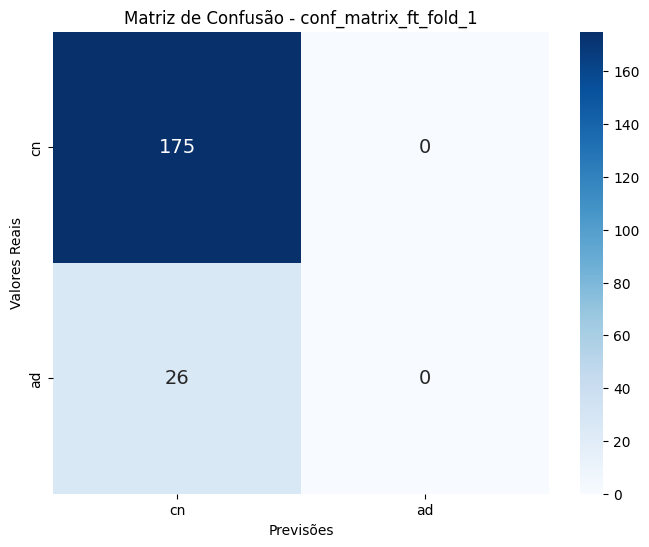

Limpando memória...

INICIANDO FOLD 2/5 (FINE-TUNING)
Gerando Augmentation e Balanceamento na RAM...
  Balanceamento: Majoritária (0): 700 | Minoritária (1): 102
Alocando memória para 1108 amostras...
Processando: 800/802...
 Dados Augmentados na RAM! Shape: (1108, 156, 195, 160, 1)
Configurando tf.data Generators...
Iniciando treinamento...
Epoch 1/50


2026-01-12 14:33:11.093726: E external/local_xla/xla/service/slow_operation_alarm.cc:65] Trying algorithm eng26{k2=0,k13=2,k14=3,k18=0,k22=0,k23=0} for conv (f32[8,4,156,195,160]{4,3,2,1,0}, u8[0]{0}) custom-call(f32[8,1,156,195,160]{4,3,2,1,0}, f32[4,1,3,3,3]{4,3,2,1,0}, f32[4]{0}), window={size=3x3x3 pad=1_1x1_1x1_1}, dim_labels=bf012_oi012->bf012, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"conv_result_scale":1,"activation_mode":"kNone","side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false} is taking a while...
2026-01-12 14:33:11.218450: E external/local_xla/xla/service/slow_operation_alarm.cc:133] The operation took 1.124786284s
Trying algorithm eng26{k2=0,k13=2,k14=3,k18=0,k22=0,k23=0} for conv (f32[8,4,156,195,160]{4,3,2,1,0}, u8[0]{0}) custom-call(f32[8,1,156,195,160]{4,3,2,1,0}, f32[4,1,3,3,3]{4,3,2,1,0}, f32[4]{0}), window={size=3x3x3 pad=1_1x1_

    138/Unknown 40s 129ms/step - accuracy: 0.6231 - auc: 0.6892 - loss: 1.3371

2026-01-12 14:33:49.545044: E external/local_xla/xla/service/slow_operation_alarm.cc:65] Trying algorithm eng20{k2=6,k3=0} for conv (f32[4,1,3,3,3]{4,3,2,1,0}, u8[0]{0}) custom-call(f32[4,1,156,195,160]{4,3,2,1,0}, f32[4,4,156,195,160]{4,3,2,1,0}), window={size=3x3x3 pad=1_1x1_1x1_1}, dim_labels=bf012_oi012->bf012, custom_call_target="__cudnn$convBackwardFilter", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"conv_result_scale":1,"activation_mode":"kNone","side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false} is taking a while...
2026-01-12 14:33:49.907562: E external/local_xla/xla/service/slow_operation_alarm.cc:133] The operation took 1.362611332s
Trying algorithm eng20{k2=6,k3=0} for conv (f32[4,1,3,3,3]{4,3,2,1,0}, u8[0]{0}) custom-call(f32[4,1,156,195,160]{4,3,2,1,0}, f32[4,4,156,195,160]{4,3,2,1,0}), window={size=3x3x3 pad=1_1x1_1x1_1}, dim_labels=bf012_oi012->bf012, custom_call_target="__cudnn$convBackward

    139/Unknown 55s 240ms/step - accuracy: 0.6234 - auc: 0.6894 - loss: 1.3367

...

2026-01-12 14:38:52.242193: I tensorflow/core/framework/local_rendezvous.cc:423] Local rendezvous recv item cancelled. Key hash: 6934646235427923232


139/139 ━━━━━━━━━━━━━━━━━━━━ 20s 140ms/step - accuracy: 0.8493 - auc: 0.8903 - loss: 0.4835 - val_accuracy: 0.1294 - val_auc: 0.4815 - val_loss: 3.9517 - learning_rate: 5.0000e-04
Epoch 17/50
  1/139 ━━━━━━━━━━━━━━━━━━━━ 22s 163ms/step - accuracy: 0.8750 - auc: 1.0000 - loss: 0.2934

2026-01-12 14:38:53.393020: I tensorflow/core/framework/local_rendezvous.cc:423] Local rendezvous recv item cancelled. Key hash: 6934646235427923232


139/139 ━━━━━━━━━━━━━━━━━━━━ 19s 139ms/step - accuracy: 0.8366 - auc: 0.8898 - loss: 0.4747 - val_accuracy: 0.8756 - val_auc: 0.6919 - val_loss: 0.5253 - learning_rate: 5.0000e-04


2026-01-12 14:39:12.679735: I tensorflow/core/framework/local_rendezvous.cc:423] Local rendezvous recv item cancelled. Key hash: 10679036752214322336
2026-01-12 14:39:12.679831: I tensorflow/core/framework/local_rendezvous.cc:423] Local rendezvous recv item cancelled. Key hash: 6934646235427923232


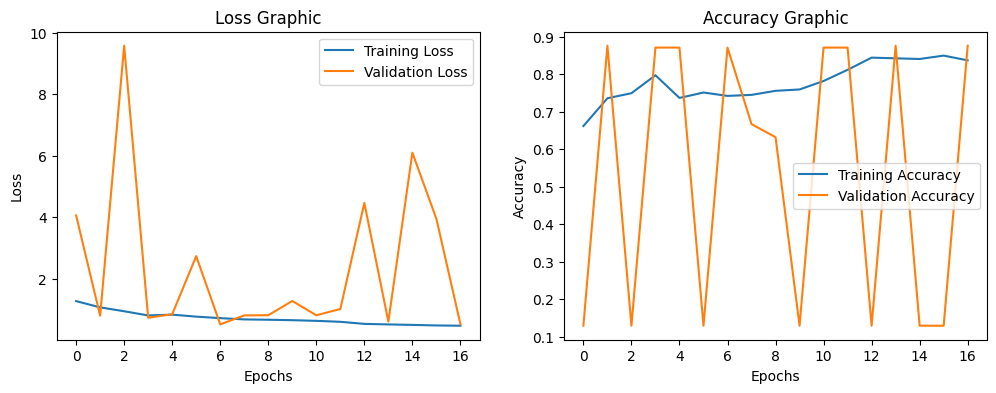

Carregando melhor modelo do fold...


2026-01-12 14:39:18.784453: I tensorflow/core/framework/local_rendezvous.cc:423] Local rendezvous recv item cancelled. Key hash: 10679036752214322336
2026-01-12 14:39:18.784534: I tensorflow/core/framework/local_rendezvous.cc:423] Local rendezvous recv item cancelled. Key hash: 6934646235427923232


  Resultado Fold 2: Acc=0.8756, AUC=0.7821
              precision    recall  f1-score   support

           0       0.88      0.99      0.93       175
           1       0.67      0.08      0.14        26

    accuracy                           0.88       201
   macro avg       0.77      0.54      0.54       201
weighted avg       0.85      0.88      0.83       201



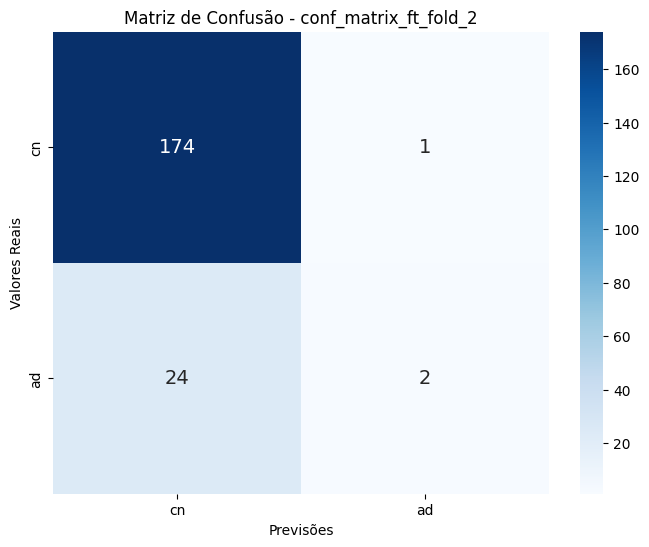

Limpando memória...

INICIANDO FOLD 3/5 (FINE-TUNING)
Gerando Augmentation e Balanceamento na RAM...
  Balanceamento: Majoritária (0): 700 | Minoritária (1): 102
Alocando memória para 1108 amostras...
Processando: 800/802...
 Dados Augmentados na RAM! Shape: (1108, 156, 195, 160, 1)
Configurando tf.data Generators...
Iniciando treinamento...
Epoch 1/50
    139/Unknown 31s 169ms/step - accuracy: 0.7018 - auc: 0.7359 - loss: 1.2995

2026-01-12 14:42:00.497143: I tensorflow/core/framework/local_rendezvous.cc:423] Local rendezvous recv item cancelled. Key hash: 10679036752214322336
2026-01-12 14:42:00.497230: I tensorflow/core/framework/local_rendezvous.cc:423] Local rendezvous recv item cancelled. Key hash: 6934646235427923232
/mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/Alzheimer-CNN-Detection/3dalz/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


139/139 ━━━━━━━━━━━━━━━━━━━━ 37s 206ms/step - accuracy: 0.7193 - auc: 0.7474 - loss: 1.2350 - val_accuracy: 0.1294 - val_auc: 0.4992 - val_loss: 4.1745 - learning_rate: 0.0010
Epoch 2/50


2026-01-12 14:42:05.577130: I tensorflow/core/framework/local_rendezvous.cc:423] Local rendezvous recv item cancelled. Key hash: 10679036752214322336
2026-01-12 14:42:05.577211: I tensorflow/core/framework/local_rendezvous.cc:423] Local rendezvous recv item cancelled. Key hash: 6934646235427923232


139/139 ━━━━━━━━━━━━━━━━━━━━ 20s 139ms/step - accuracy: 0.7374 - auc: 0.7841 - loss: 1.0564 - val_accuracy: 0.1294 - val_auc: 0.6043 - val_loss: 1.8414 - learning_rate: 0.0010
Epoch 3/50
139/139 ━━━━━━━━━━━━━━━━━━━━ 19s 139ms/step - accuracy: 0.7437 - auc: 0.7822 - loss: 0.9401 - val_accuracy: 0.1294 - val_auc: 0.6137 - val_loss: 1.8897 - learning_rate: 0.0010
Epoch 4/50
  1/139 ━━━━━━━━━━━━━━━━━━━━ 22s 161ms/step - accuracy: 0.8750 - auc: 0.8667 - loss: 0.7359

...

2026-01-12 14:47:53.475089: I tensorflow/core/framework/local_rendezvous.cc:423] Local rendezvous recv item cancelled. Key hash: 10679036752214322336
2026-01-12 14:47:53.475201: I tensorflow/core/framework/local_rendezvous.cc:423] Local rendezvous recv item cancelled. Key hash: 6934646235427923232


139/139 ━━━━━━━━━━━━━━━━━━━━ 19s 139ms/step - accuracy: 0.8529 - auc: 0.9130 - loss: 0.4468 - val_accuracy: 0.1294 - val_auc: 0.5011 - val_loss: 4.2873 - learning_rate: 2.5000e-04
Epoch 20/50
139/139 ━━━━━━━━━━━━━━━━━━━━ 19s 139ms/step - accuracy: 0.8601 - auc: 0.9121 - loss: 0.4461 - val_accuracy: 0.1294 - val_auc: 0.5481 - val_loss: 1.3604 - learning_rate: 2.5000e-04
Epoch 21/50
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - accuracy: 0.8600 - auc: 0.9171 - loss: 0.4340

2026-01-12 14:48:32.339067: I tensorflow/core/framework/local_rendezvous.cc:423] Local rendezvous recv item cancelled. Key hash: 10679036752214322336
2026-01-12 14:48:32.339178: I tensorflow/core/framework/local_rendezvous.cc:423] Local rendezvous recv item cancelled. Key hash: 6934646235427923232


139/139 ━━━━━━━━━━━━━━━━━━━━ 19s 140ms/step - accuracy: 0.8601 - auc: 0.9197 - loss: 0.4290 - val_accuracy: 0.1294 - val_auc: 0.5926 - val_loss: 1.9855 - learning_rate: 2.5000e-04


2026-01-12 14:48:33.493522: I tensorflow/core/framework/local_rendezvous.cc:423] Local rendezvous recv item cancelled. Key hash: 10679036752214322336


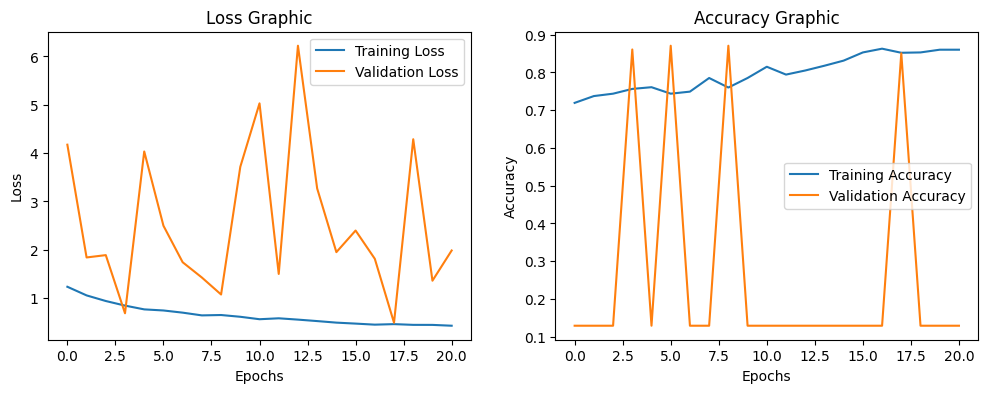

Carregando melhor modelo do fold...


2026-01-12 14:48:39.756039: I tensorflow/core/framework/local_rendezvous.cc:423] Local rendezvous recv item cancelled. Key hash: 10679036752214322336
2026-01-12 14:48:39.756113: I tensorflow/core/framework/local_rendezvous.cc:423] Local rendezvous recv item cancelled. Key hash: 6934646235427923232


  Resultado Fold 3: Acc=0.8706, AUC=0.5000


/mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/Alzheimer-CNN-Detection/3dalz/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/Alzheimer-CNN-Detection/3dalz/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/Alzheimer-CNN-Detection/3dalz/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no

              precision    recall  f1-score   support

           0       0.87      1.00      0.93       175
           1       0.00      0.00      0.00        26

    accuracy                           0.87       201
   macro avg       0.44      0.50      0.47       201
weighted avg       0.76      0.87      0.81       201



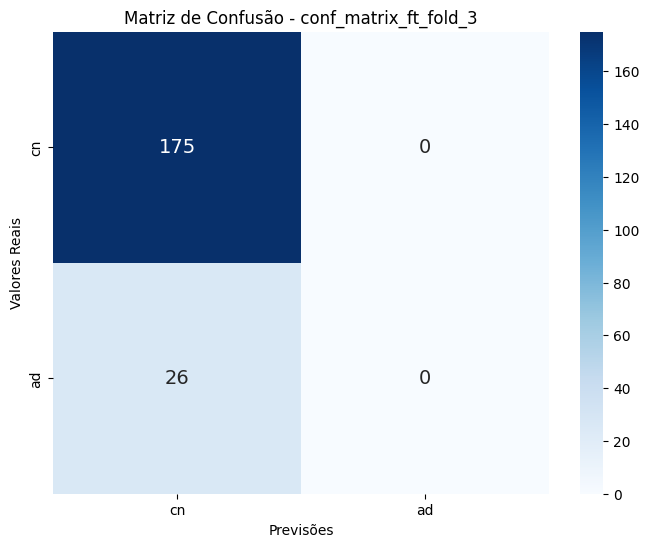

Limpando memória...

INICIANDO FOLD 4/5 (FINE-TUNING)
Gerando Augmentation e Balanceamento na RAM...
  Balanceamento: Majoritária (0): 700 | Minoritária (1): 103
Alocando memória para 1112 amostras...
Processando: 800/803...
 Dados Augmentados na RAM! Shape: (1112, 156, 195, 160, 1)
Configurando tf.data Generators...
Iniciando treinamento...
Epoch 1/50
    139/Unknown 29s 131ms/step - accuracy: 0.6564 - auc: 0.7053 - loss: 1.3074

/mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/Alzheimer-CNN-Detection/3dalz/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()
2026-01-12 14:52:32.752670: I tensorflow/core/framework/local_rendezvous.cc:423] Local rendezvous recv item cancelled. Key hash: 10679036752214322336
2026-01-12 14:52:32.753107: I tensorflow/core/framework/local_rendezvous.cc:423] Local rendezvous recv item cancelled. Key hash: 6934646235427923232


139/139 ━━━━━━━━━━━━━━━━━━━━ 32s 154ms/step - accuracy: 0.6933 - auc: 0.7366 - loss: 1.2280 - val_accuracy: 0.1250 - val_auc: 0.5697 - val_loss: 3.7424 - learning_rate: 0.0010
Epoch 2/50
139/139 ━━━━━━━━━━━━━━━━━━━━ 20s 140ms/step - accuracy: 0.7374 - auc: 0.8012 - loss: 0.9943 - val_accuracy: 0.8700 - val_auc: 0.5112 - val_loss: 1.4680 - learning_rate: 0.0010
Epoch 3/50
139/139 ━━━━━━━━━━━━━━━━━━━━ 19s 139ms/step - accuracy: 0.7491 - auc: 0.7976 - loss: 0.8876 - val_accuracy: 0.1250 - val_auc: 0.6978 - val_loss: 3.3241 - learning_rate: 0.0010
Epoch 4/50
  1/139 ━━━━━━━━━━━━━━━━━━━━ 22s 162ms/step - accuracy: 0.8750 - auc: 1.0000 - loss: 0.6179

2026-01-12 14:53:11.863937: I tensorflow/core/framework/local_rendezvous.cc:423] Local rendezvous recv item cancelled. Key hash: 10679036752214322336
2026-01-12 14:53:11.864020: I tensorflow/core/framework/local_rendezvous.cc:423] Local rendezvous recv item cancelled. Key hash: 6934646235427923232


139/139 ━━━━━━━━━━━━━━━━━━━━ 20s 141ms/step - accuracy: 0.7428 - auc: 0.8034 - loss: 0.7887 - val_accuracy: 0.8500 - val_auc: 0.7295 - val_loss: 0.6424 - learning_rate: 0.0010
Epoch 5/50
139/139 ━━━━━━━━━━━━━━━━━━━━ 19s 140ms/step - accuracy: 0.7635 - auc: 0.7996 - loss: 0.7315 - val_accuracy: 0.1550 - val_auc: 0.7141 - val_loss: 1.2643 - learning_rate: 0.0010
Epoch 6/50
  1/139 ━━━━━━━━━━━━━━━━━━━━ 23s 168ms/step - accuracy: 0.8750 - auc: 0.9333 - loss: 0.5260

...

2026-01-12 14:56:46.639535: I tensorflow/core/framework/local_rendezvous.cc:423] Local rendezvous recv item cancelled. Key hash: 10679036752214322336


139/139 ━━━━━━━━━━━━━━━━━━━━ 20s 141ms/step - accuracy: 0.7896 - auc: 0.8420 - loss: 0.5670 - val_accuracy: 0.8650 - val_auc: 0.7367 - val_loss: 0.5069 - learning_rate: 5.0000e-04
Epoch 16/50
139/139 ━━━━━━━━━━━━━━━━━━━━ 19s 140ms/step - accuracy: 0.7905 - auc: 0.8402 - loss: 0.5614 - val_accuracy: 0.4600 - val_auc: 0.7537 - val_loss: 0.8381 - learning_rate: 5.0000e-04
Epoch 17/50
  1/139 ━━━━━━━━━━━━━━━━━━━━ 22s 165ms/step - accuracy: 1.0000 - auc: 1.0000 - loss: 0.3881

2026-01-12 14:57:25.734268: I tensorflow/core/framework/local_rendezvous.cc:423] Local rendezvous recv item cancelled. Key hash: 10679036752214322336


139/139 ━━━━━━━━━━━━━━━━━━━━ 20s 141ms/step - accuracy: 0.7788 - auc: 0.8339 - loss: 0.5690 - val_accuracy: 0.3250 - val_auc: 0.7618 - val_loss: 0.8787 - learning_rate: 5.0000e-04


2026-01-12 14:57:45.357465: I tensorflow/core/framework/local_rendezvous.cc:423] Local rendezvous recv item cancelled. Key hash: 10679036752214322336
2026-01-12 14:57:45.357561: I tensorflow/core/framework/local_rendezvous.cc:423] Local rendezvous recv item cancelled. Key hash: 6934646235427923232


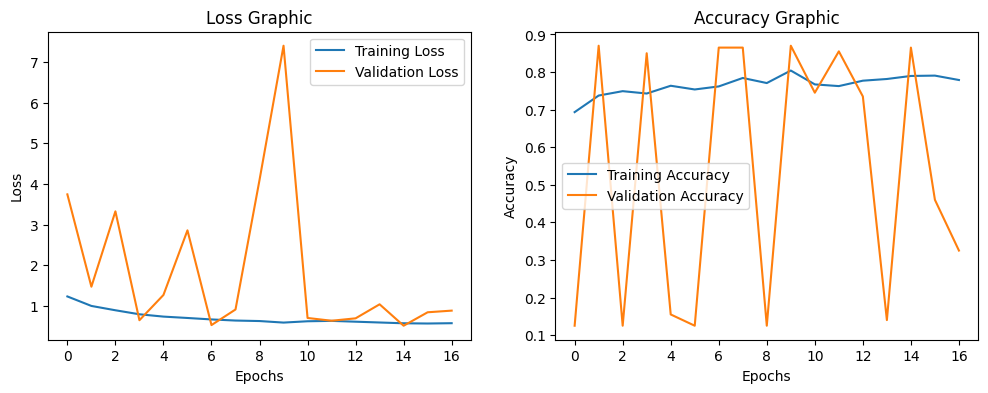

Carregando melhor modelo do fold...
  Resultado Fold 4: Acc=0.8700, AUC=0.5112
              precision    recall  f1-score   support

           0       0.87      0.99      0.93       175
           1       0.00      0.00      0.00        25

    accuracy                           0.87       200
   macro avg       0.44      0.50      0.47       200
weighted avg       0.77      0.87      0.81       200



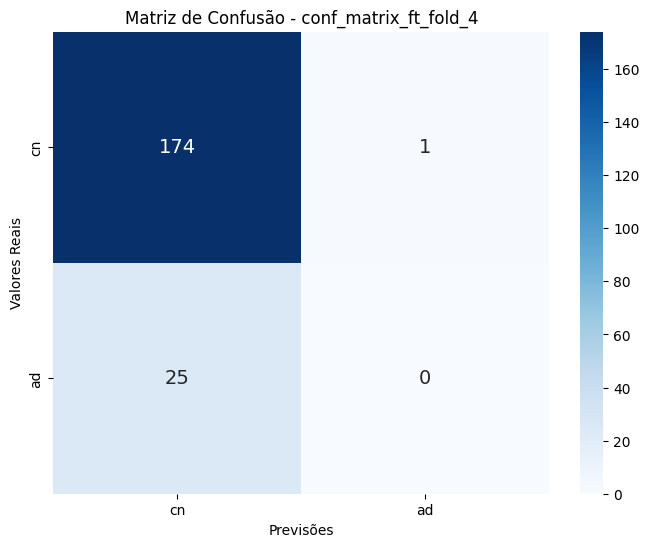

Limpando memória...

INICIANDO FOLD 5/5 (FINE-TUNING)
Gerando Augmentation e Balanceamento na RAM...
  Balanceamento: Majoritária (0): 700 | Minoritária (1): 103
Alocando memória para 1112 amostras...
Processando: 800/803...
 Dados Augmentados na RAM! Shape: (1112, 156, 195, 160, 1)
Configurando tf.data Generators...
Iniciando treinamento...
Epoch 1/50
    139/Unknown 26s 131ms/step - accuracy: 0.6247 - auc: 0.6927 - loss: 1.3712

2026-01-12 15:01:12.556741: I tensorflow/core/framework/local_rendezvous.cc:423] Local rendezvous recv item cancelled. Key hash: 10679036752214322336
/mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/Alzheimer-CNN-Detection/3dalz/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


139/139 ━━━━━━━━━━━━━━━━━━━━ 30s 155ms/step - accuracy: 0.6646 - auc: 0.7247 - loss: 1.2773 - val_accuracy: 0.1250 - val_auc: 0.6885 - val_loss: 4.1411 - learning_rate: 0.0010
Epoch 2/50
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - accuracy: 0.6957 - auc: 0.7505 - loss: 1.1115

2026-01-12 15:01:34.211394: I tensorflow/core/framework/local_rendezvous.cc:423] Local rendezvous recv item cancelled. Key hash: 10679036752214322336


139/139 ━━━━━━━━━━━━━━━━━━━━ 20s 142ms/step - accuracy: 0.7014 - auc: 0.7361 - loss: 1.0904 - val_accuracy: 0.6750 - val_auc: 0.7821 - val_loss: 1.0703 - learning_rate: 0.0010
Epoch 3/50


...

139/139 ━━━━━━━━━━━━━━━━━━━━ 20s 141ms/step - accuracy: 0.7464 - auc: 0.7735 - loss: 0.6152 - val_accuracy: 0.8800 - val_auc: 0.8177 - val_loss: 0.4716 - learning_rate: 5.0000e-04
Epoch 19/50


2026-01-12 15:06:50.649194: I tensorflow/core/framework/local_rendezvous.cc:423] Local rendezvous recv item cancelled. Key hash: 10679036752214322336


139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step - accuracy: 0.7339 - auc: 0.7717 - loss: 0.6171

2026-01-12 15:07:09.584337: I tensorflow/core/framework/local_rendezvous.cc:423] Local rendezvous recv item cancelled. Key hash: 10679036752214322336


139/139 ━━━━━━━━━━━━━━━━━━━━ 20s 146ms/step - accuracy: 0.7599 - auc: 0.7905 - loss: 0.5973 - val_accuracy: 0.1250 - val_auc: 0.7675 - val_loss: 2.0275 - learning_rate: 5.0000e-04


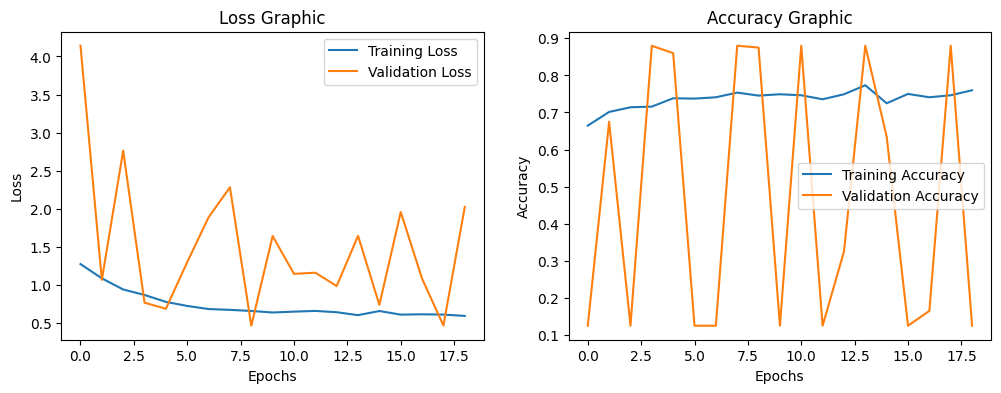

Carregando melhor modelo do fold...


2026-01-12 15:07:14.968055: I tensorflow/core/framework/local_rendezvous.cc:423] Local rendezvous recv item cancelled. Key hash: 10679036752214322336
2026-01-12 15:07:14.968150: I tensorflow/core/framework/local_rendezvous.cc:423] Local rendezvous recv item cancelled. Key hash: 6934646235427923232


  Resultado Fold 5: Acc=0.8800, AUC=0.7659
              precision    recall  f1-score   support

           0       0.88      1.00      0.94       175
           1       1.00      0.04      0.08        25

    accuracy                           0.88       200
   macro avg       0.94      0.52      0.51       200
weighted avg       0.89      0.88      0.83       200



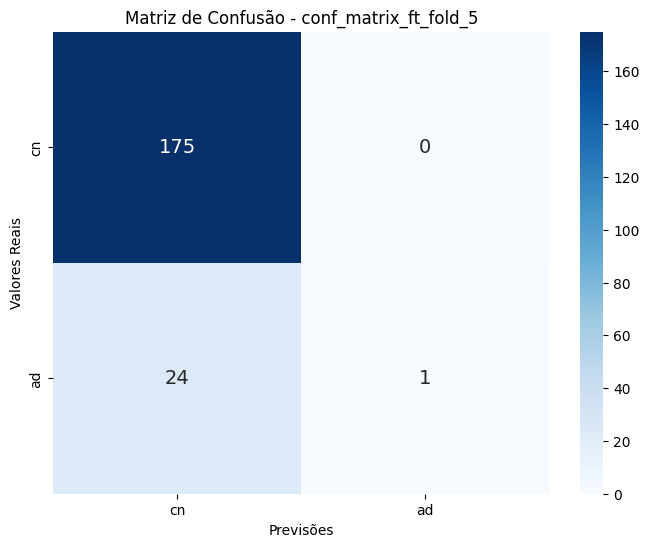

Limpando memória...


In [9]:
# LOOP PRINCIPAL (FINE-TUNING K-FOLD)
skf = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=42)

for fold_idx, (train_index, val_index) in enumerate(skf.split(X_all, y_all)):
    print(f"\n{'='*40}")
    print(f"INICIANDO FOLD {fold_idx+1}/{K_FOLDS} (FINE-TUNING)")
    print(f"{'='*40}")

    fold_dir = os.path.join(results_dir, f"fold_ft_{fold_idx+1}")
    os.makedirs(fold_dir, exist_ok=True)

    # --- 1. PREPARAÇÃO DOS DADOS ---
    X_val_fold = X_all[val_index]
    if len(X_val_fold.shape) == 3:
        X_val_fold = np.expand_dims(X_val_fold, axis=-1)
    X_val_fold = X_val_fold.astype(np.float16)
    y_val_fold = y_all[val_index]

    print("Gerando Augmentation e Balanceamento na RAM...")
    try:
        X_train_aug, y_train_aug = augment_and_balance_in_ram(X_all, y_all, train_index)
    except MemoryError:
        print("FATAL: Memória insuficiente.")
        break

    # --- 2. CONFIGURAR GENERATORS (TF.DATA) ---
    print("Configurando tf.data Generators...")
    
    # Especificações (atenção ao float16 do treino)
    train_spec_img = tf.TensorSpec(shape=X_train_aug.shape[1:], dtype=tf.float16)
    train_spec_lbl = tf.TensorSpec(shape=(), dtype=tf.int16)
    
    val_spec_img = tf.TensorSpec(shape=X_val_fold.shape[1:], dtype=tf.float16)
    val_spec_lbl = tf.TensorSpec(shape=(), dtype=tf.int16)

    # Dataset Treino
    train_dataset = tf.data.Dataset.from_generator(
        lambda: numpy_generator(X_train_aug, y_train_aug),
        output_signature=(train_spec_img, train_spec_lbl)
    )
    train_dataset = train_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

    # Dataset Validação
    val_dataset = tf.data.Dataset.from_generator(
        lambda: numpy_generator(X_val_fold, y_val_fold),
        output_signature=(val_spec_img, val_spec_lbl)
    )
    val_dataset = val_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

    # --- 3. MODELO ---
    input_shape = X_train_aug.shape[1:] # (156, 195, 160, 1)
    
    # Cria arquitetura
    model = create_model_3d(input_shape, 2)

    # Compila (LR Baixo)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE), 
        loss='binary_crossentropy', 
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
    )
    
    # Callbacks
    model_name = f"model_fold_{fold_idx+1}.keras"
    model_save_path = os.path.join(fold_dir, model_name)
    
    checkpoint = ModelCheckpoint(model_save_path, monitor='val_accuracy', save_best_only=True, mode='max', verbose=0)
    early_stop = EarlyStopping(monitor='val_accuracy', patience=15, restore_best_weights=True)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5)
    csv_log = CSVLogger(os.path.join(fold_dir, 'training_log.csv'))

    # --- 4. TREINAMENTO ---
    print("Iniciando treinamento...")
    history = model.fit(
        train_dataset,
        epochs=EPOCHS,
        validation_data=val_dataset,
        callbacks=[checkpoint, early_stop, reduce_lr, csv_log],
        verbose=1
    )
    
    # Salva gráfico histórico
    try: met_vil.plot_training_history_binary(history, fold_dir)
    except: pass

    # --- 5. AVALIAÇÃO E PREDIÇÃO ---
    print("Carregando melhor modelo do fold...")
    best_model = models.load_model(model_save_path)
    
    # Avaliação numérica
    loss, acc, auc = best_model.evaluate(val_dataset, verbose=0)
    fold_accuracies.append(acc)
    fold_aucs.append(auc)
    print(f"  Resultado Fold {fold_idx+1}: Acc={acc:.4f}, AUC={auc:.4f}")

    # Predição
    pred_labels, true_labels, preds_prob = met_vil.get_predictions_binary(X_val_fold, y_val_fold, BATCH_SIZE, best_model)
    
    # Relatórios
    met_vil.get_classification_report(true_labels, pred_labels, fold_dir, f'report_ft_fold_{fold_idx+1}')
    met_vil.plot_confusion_matrix(true_labels, pred_labels, fold_dir, f'conf_matrix_ft_fold_{fold_idx+1}', adni_class_names)

    # Acumula para relatório global
    aggregated_true_labels.extend(true_labels)
    aggregated_pred_labels.extend(pred_labels)

    # --- LIMPEZA DE MEMÓRIA ---
    print("Limpando memória...")
    del X_train_aug, y_train_aug, X_val_fold, y_val_fold
    del train_dataset, val_dataset, model, best_model, history
    tf.keras.backend.clear_session()
    gc.collect()


GERANDO RESULTADOS AGREGADOS
Gerando Matriz de Confusão Agregada...


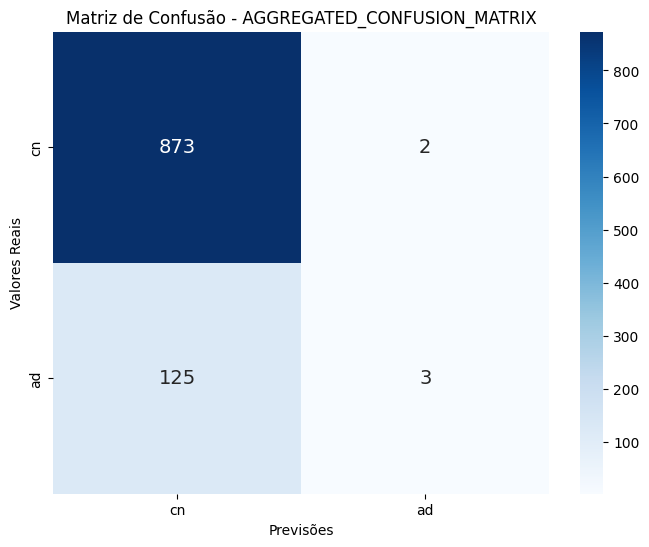

Gerando Relatório de Classificação Agregado...
              precision    recall  f1-score   support

           0       0.87      1.00      0.93       875
           1       0.60      0.02      0.05       128

    accuracy                           0.87      1003
   macro avg       0.74      0.51      0.49      1003
weighted avg       0.84      0.87      0.82      1003


Média Acurácia: 0.8734 (+/- 0.0039)
Média AUC: 0.6588 (+/- 0.1261)


In [10]:
# 5. RESULTADOS FINAIS E MATRIZ AGREGADA
print("\n" + "="*40)
print("GERANDO RESULTADOS AGREGADOS")
print("="*40)

# Converter listas acumuladas para numpy arrays para compatibilidade
final_true = np.array(aggregated_true_labels)
final_pred = np.array(aggregated_pred_labels)

# ### NOVO: Gerar Matriz de Confusão Agregada
print("Gerando Matriz de Confusão Agregada...")
met_vil.plot_confusion_matrix(
    final_true, 
    final_pred, 
    results_dir,  # Salva na pasta raiz do experimento (não dentro de fold_X)
    'AGGREGATED_CONFUSION_MATRIX', 
    adni_class_names
)

# ### NOVO: Relatório de Classificação Agregado
print("Gerando Relatório de Classificação Agregado...")
met_vil.get_classification_report(
    final_true, 
    final_pred, 
    results_dir, 
    'AGGREGATED_CLASSIFICATION_REPORT'
)

print(f"\nMédia Acurácia: {np.mean(fold_accuracies):.4f} (+/- {np.std(fold_accuracies):.4f})")
print(f"Média AUC: {np.mean(fold_aucs):.4f} (+/- {np.std(fold_aucs):.4f})")

# Salvar resumo final em texto
with open(os.path.join(results_dir, "final_kfold_summary.txt"), "w") as f:
    f.write(f"Mean Accuracy: {np.mean(fold_accuracies):.4f} +/- {np.std(fold_accuracies):.4f}\n")
    f.write(f"Mean AUC: {np.mean(fold_aucs):.4f} +/- {np.std(fold_aucs):.4f}\n")
    f.write(f"Fold Accuracies: {fold_accuracies}\n")
    f.write(f"\n--- Aggregated Metrics ---\n")
    
    # Podemos adicionar métricas simples calculadas sobre o total
    from sklearn.metrics import accuracy_score
    total_acc = accuracy_score(final_true, final_pred)
    f.write(f"Total Aggregated Accuracy: {total_acc:.4f}\n")